# **Telecom X — Parte 2: Predicción de Cancelación (Churn)**

## 📦 Preparación de los Datos

### Extracción del Archivo Tratado

Se carga el archivo CSV resultante de la Parte 1 del desafío, el cual contiene
los datos ya limpios, normalizados y estandarizados, listos para el modelado predictivo.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

datos = pd.read_csv('datos_tratados.csv')
datos.head()

,ID_Cliente,Abandono,Genero,Adulto_Mayor,Pareja,Dependientes,Meses_Contrato,Servicio_Telefono,Lineas_Multiples,Servicio_Internet,...,Proteccion_Dispositivo,Soporte_Tecnico,Streaming_TV,Streaming_Peliculas,Tipo_Contrato,Factura_Digital,Metodo_Pago,Cargos_Mensuales,Cargos_Totales,Cuentas_Diarias
0,0002-ORFBO,0,0,0,1,1,9,1,0,DSL,...,0,1,1,0,One year,1,Mailed check,65.6,593.30,2.19
1,0003-MKNFE,0,1,0,0,0,9,1,1,DSL,...,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.40,2.00
2,0004-TLHLJ,1,1,0,0,0,4,1,0,Fiber optic,...,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,1,1,1,1,0,13,1,0,Fiber optic,...,1,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,1,0,1,1,0,3,1,0,Fiber optic,...,0,1,1,0,Month-to-month,1,Mailed check,83.9,267.40,2.80


In [9]:
datos.shape

(7043, 22)

### Eliminación de Columnas Irrelevantes

Se elimina la columna `ID_Cliente` ya que es un identificador único que no aporta
información predictiva y puede perjudicar el desempeño de los modelos. También se
elimina `Cuentas_Diarias` por ser una variable derivada directamente de `Cargos_Mensuales`,
lo que introduciría redundancia en el modelo.

In [10]:
datos = datos.drop(columns=['ID_Cliente', 'Cuentas_Diarias'])
datos.shape

(7043, 20)

### Encoding de Variables Categóricas

Se aplica One-Hot Encoding a las variables categóricas restantes (`Servicio_Internet`,
`Tipo_Contrato`, `Metodo_Pago`) para convertirlas a formato numérico compatible con
los algoritmos de machine learning.

In [11]:
columnas_categoricas = ['Servicio_Internet', 'Tipo_Contrato', 'Metodo_Pago']

datos = pd.get_dummies(data=datos, columns=columnas_categoricas, dtype=int)
datos.shape

(7043, 27)

In [13]:
datos.columns

Index(['Abandono', 'Genero', 'Adulto_Mayor', 'Pareja', 'Dependientes',
       'Meses_Contrato', 'Servicio_Telefono', 'Lineas_Multiples',
       'Seguridad_Online', 'Respaldo_Online', 'Proteccion_Dispositivo',
       'Soporte_Tecnico', 'Streaming_TV', 'Streaming_Peliculas',
       'Factura_Digital', 'Cargos_Mensuales', 'Cargos_Totales',
       'Servicio_Internet_DSL', 'Servicio_Internet_Fiber optic',
       'Servicio_Internet_No', 'Tipo_Contrato_Month-to-month',
       'Tipo_Contrato_One year', 'Tipo_Contrato_Two year',
       'Metodo_Pago_Bank transfer (automatic)',
       'Metodo_Pago_Credit card (automatic)', 'Metodo_Pago_Electronic check',
       'Metodo_Pago_Mailed check'],
      dtype='object')

### Verificación de la Proporción de Cancelación (Churn)

Se calcula la proporción de clientes que cancelaron versus los que permanecieron,
con el fin de identificar si existe un desbalance entre clases que pueda afectar
el desempeño de los modelos predictivos.

In [14]:
datos['Abandono'].value_counts(normalize=True).mul(100).round(2)

,proportion
Abandono,
0,73.46
1,26.54


### Balanceo de Clases

Dado el desbalance identificado (aproximadamente 73.5% vs 26.5%), se aplica
**SMOTE (Synthetic Minority Oversampling Technique)**, que genera ejemplos sintéticos
de la clase minoritaria (clientes que cancelaron) para equilibrar ambas clases.
Este balanceo se aplicará dentro del pipeline de entrenamiento para evitar
contaminación entre los datos de entrenamiento y prueba.

In [15]:
# Separación de variables predictoras y variable objetivo
X = datos.drop(columns='Abandono')
y = datos['Abandono']

# Verificación del desbalance antes del balanceo
y.value_counts(normalize=True).mul(100).round(2)

,proportion
Abandono,
0,73.46
1,26.54


### Normalización de los Datos

Se aplica estandarización con **StandardScaler** a las variables numéricas continuas.
Esto es necesario para los modelos basados en distancia o en optimización de parámetros,
como la **Regresión Logística**, ya que sin normalización las variables con mayor magnitud
dominarían el cálculo. Los modelos basados en árboles como **Random Forest** no requieren
este paso, pero se usará el mismo conjunto para mantener consistencia en la comparación.

In [17]:
from sklearn.preprocessing import StandardScaler

columnas_numericas = ['Meses_Contrato', 'Cargos_Mensuales', 'Cargos_Totales']

scaler = StandardScaler()
X[columnas_numericas] = scaler.fit_transform(X[columnas_numericas])

X.head()

,Genero,Adulto_Mayor,Pareja,Dependientes,Meses_Contrato,Servicio_Telefono,Lineas_Multiples,Seguridad_Online,Respaldo_Online,Proteccion_Dispositivo,...,Servicio_Internet_DSL,Servicio_Internet_Fiber optic,Servicio_Internet_No,Tipo_Contrato_Month-to-month,Tipo_Contrato_One year,Tipo_Contrato_Two year,Metodo_Pago_Bank transfer (automatic),Metodo_Pago_Credit card (automatic),Metodo_Pago_Electronic check,Metodo_Pago_Mailed check
0,0,0,1,1,-0.951682,1,0,0,1,0,...,1,0,0,0,1,0,0,0,0,1
1,1,0,0,0,-0.951682,1,1,0,0,0,...,1,0,0,1,0,0,0,0,0,1
2,1,0,0,0,-1.155283,1,0,0,0,1,...,0,1,0,1,0,0,0,0,1,0
3,1,1,1,0,-0.788800,1,0,0,1,1,...,0,1,0,1,0,0,0,0,1,0
4,0,1,1,0,-1.196004,1,0,0,0,0,...,0,1,0,1,0,0,0,0,0,1


---
## 🔗 Correlación y Selección de Variables

### Análisis de Correlación

Se visualiza la matriz de correlación entre todas las variables numéricas para
identificar relaciones entre ellas y con la variable objetivo `Abandono`.
Las variables con mayor correlación con el abandono son candidatas clave para el modelo predictivo.

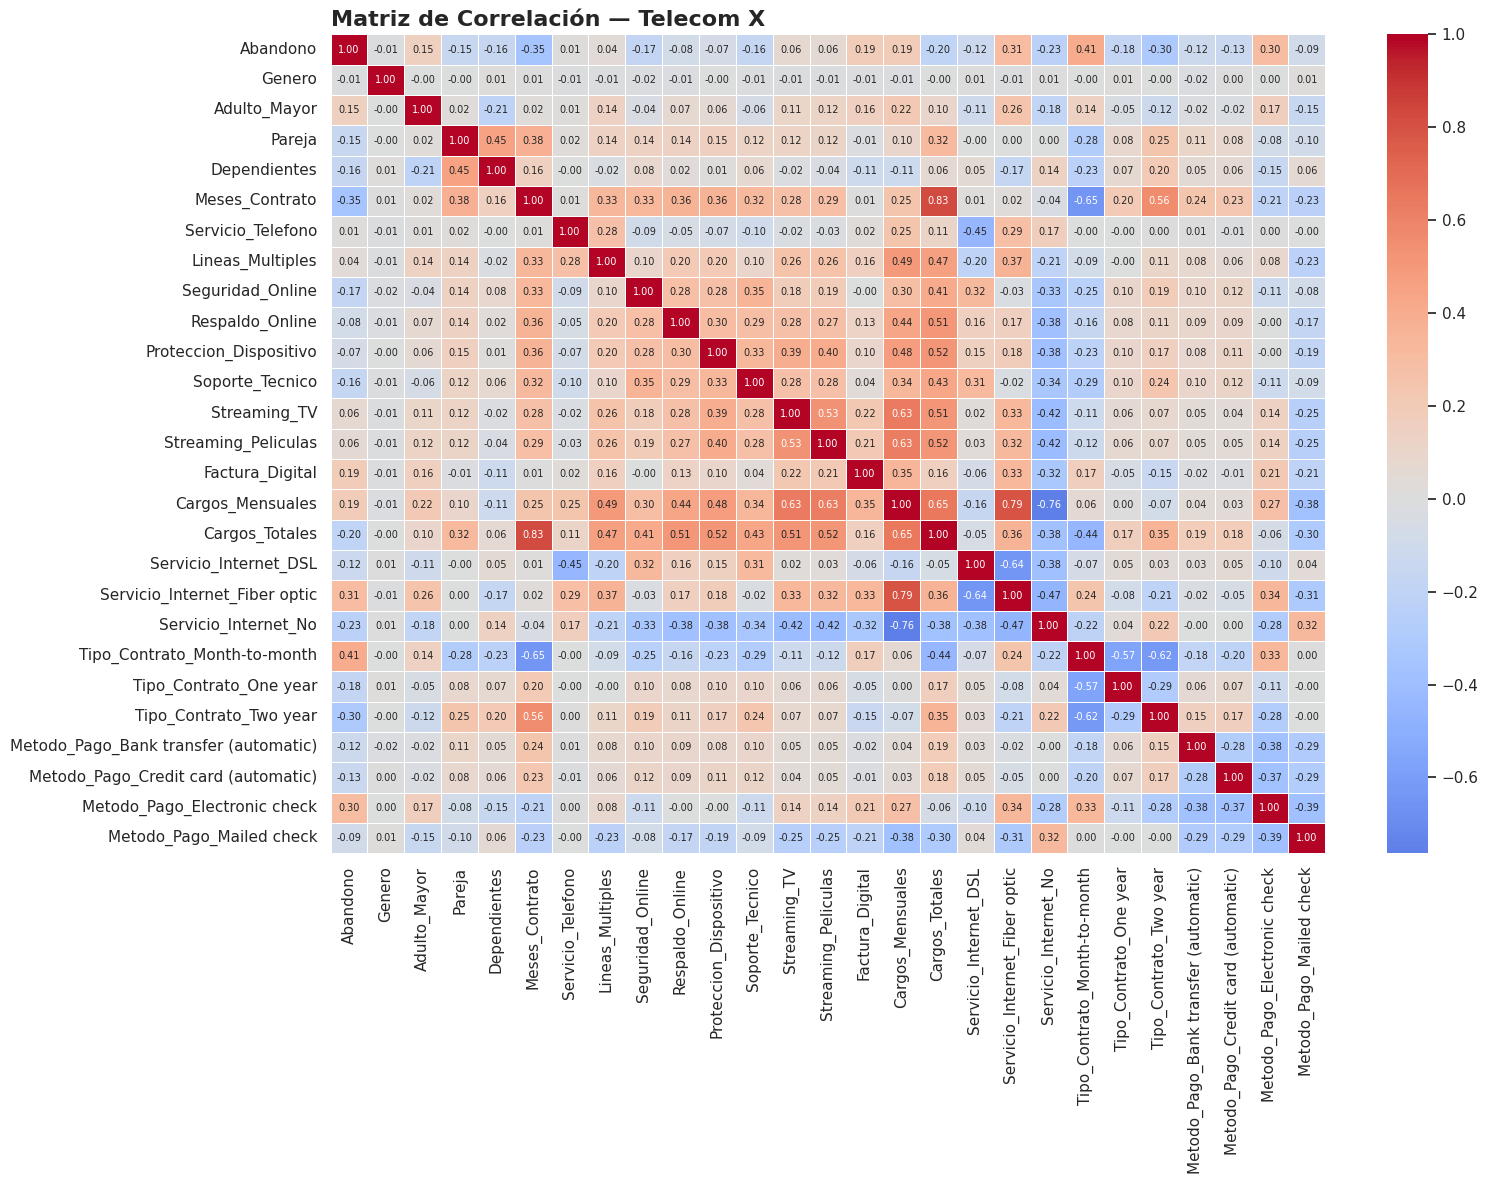

In [18]:
sns.set_theme(style='whitegrid')

fig, ax = plt.subplots(figsize=(16, 12))

correlacion = datos.corr()

sns.heatmap(correlacion,
            annot=True, fmt='.2f',
            cmap='coolwarm', center=0,
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 7},
            ax=ax)

ax.set_title('Matriz de Correlación — Telecom X', fontsize=16, fontweight='bold', loc='left')
plt.tight_layout()
plt.show()

### Análisis Dirigido: Variables Clave vs Cancelación

Se analizan específicamente las variables `Meses_Contrato` y `Cargos_Totales` en
relación con la cancelación, utilizando boxplots para visualizar si existen diferencias
significativas en la distribución entre clientes que abandonaron y los que permanecieron.

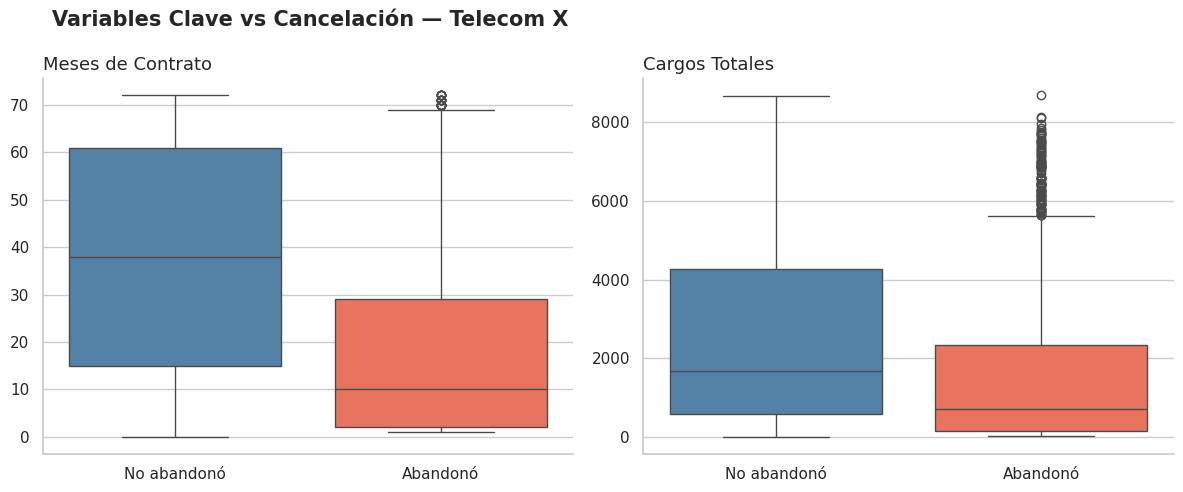

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Variables Clave vs Cancelación — Telecom X',
             fontsize=15, fontweight='bold', x=0.05, ha='left')

for ax, col, titulo in zip(axes,
                            ['Meses_Contrato', 'Cargos_Totales'],
                            ['Meses de Contrato', 'Cargos Totales']):
    sns.boxplot(data=datos, x='Abandono', y=col,
                hue='Abandono', palette={0: 'steelblue', 1: 'tomato'},
                legend=False, ax=ax)
    ax.set_title(titulo, loc='left', fontsize=13)
    ax.set_xlabel('')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['No abandonó', 'Abandonó'])
    ax.set_ylabel('')
    sns.despine()

plt.tight_layout()
plt.show()

---

## 🧠 Modelado Predictivo

### Separación de Datos

Se divide el conjunto de datos en entrenamiento (80%) y prueba (20%), utilizando
`stratify=y` para mantener la misma proporción de cancelación en ambos conjuntos,
lo cual es importante dado el desbalance de clases existente.

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train.shape, X_test.shape

((5634, 26), (1409, 26))

### Modelo 1: Regresión Logística

Se entrena una Regresión Logística, modelo lineal que estima la probabilidad de
cancelación para cada cliente. Este modelo requiere que los datos estén normalizados,
condición que ya fue aplicada en la etapa de preparación. Se aplica SMOTE dentro
del pipeline para balancear las clases solo sobre los datos de entrenamiento,
evitando contaminación con los datos de prueba.

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as imbpipeline

pipeline_lr = imbpipeline([
    ('smote', SMOTE(random_state=42)),
    ('modelo', LogisticRegression(max_iter=1000, random_state=42))
])

pipeline_lr.fit(X_train, y_train)
y_pred_lr = pipeline_lr.predict(X_test)

print(classification_report(y_test, y_pred_lr, target_names=['No abandonó', 'Abandonó']))

              precision    recall  f1-score   support

 No abandonó       0.89      0.78      0.83      1035
    Abandonó       0.55      0.73      0.63       374

    accuracy                           0.77      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.77      0.78      1409



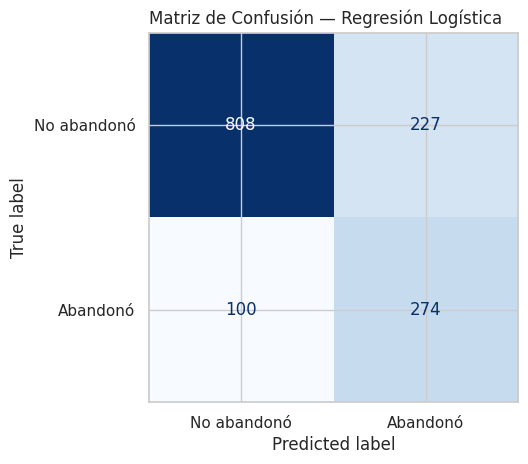

In [23]:
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr,
    display_labels=['No abandonó', 'Abandonó'],
    colorbar=False,
    cmap='Blues'
)
plt.title('Matriz de Confusión — Regresión Logística', loc='left')
plt.show()

Regresión Logística:
*   Accuracy: 77%, correcto en 3 de cada 4 clientes
*   Recall de Abandonó: 73%, detecta el 73% de los clientes que realmente cancelaron, que es la métrica más importante para el negocio
*   Precisión de Abandonó: 55%, de los que predice como "abandonará", el 55% realmente abandona
*   El modelo tiene un balance razonable entre clases gracias al SMOTE

### Modelo 2: Random Forest

Se entrena un modelo Random Forest, un ensamble de árboles de decisión que no
requiere normalización de datos. Se aplica igualmente SMOTE en el pipeline para
mantener consistencia en el tratamiento del desbalance de clases.

In [24]:
from sklearn.ensemble import RandomForestClassifier

pipeline_rf = imbpipeline([
    ('smote', SMOTE(random_state=42)),
    ('modelo', RandomForestClassifier(n_estimators=100, random_state=42))
])

pipeline_rf.fit(X_train, y_train)
y_pred_rf = pipeline_rf.predict(X_test)

print(classification_report(y_test, y_pred_rf, target_names=['No abandonó', 'Abandonó']))

              precision    recall  f1-score   support

 No abandonó       0.86      0.82      0.84      1035
    Abandonó       0.56      0.63      0.59       374

    accuracy                           0.77      1409
   macro avg       0.71      0.72      0.72      1409
weighted avg       0.78      0.77      0.77      1409



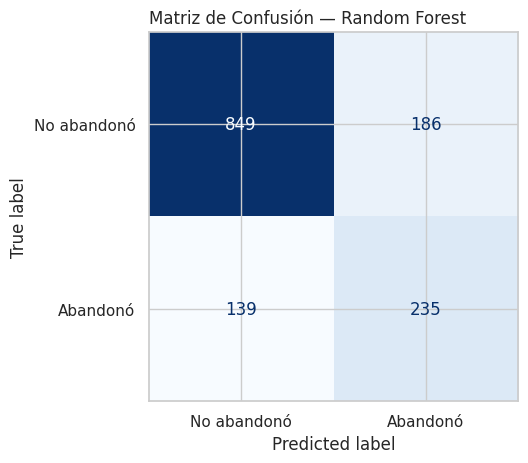

In [25]:
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf,
    display_labels=['No abandonó', 'Abandonó'],
    colorbar=False,
    cmap='Blues'
)
plt.title('Matriz de Confusión — Random Forest', loc='left')
plt.show()

### Comparación de Modelos

Se comparan las métricas principales de ambos modelos para determinar cuál tiene
mejor desempeño en la predicción de cancelación de clientes.

In [26]:
comparacion = pd.DataFrame({
    'Métrica'    : ['Accuracy', 'Precisión (Abandonó)', 'Recall (Abandonó)', 'F1-Score (Abandonó)'],
    'Reg. Logística': [0.77, 0.55, 0.73, 0.63],
    'Random Forest' : [0.77, 0.56, 0.63, 0.59]
})

comparacion.set_index('Métrica')

,Reg. Logística,Random Forest
Métrica,,
Accuracy,0.77,0.77
Precisión (Abandonó),0.55,0.56
Recall (Abandonó),0.73,0.63
F1-Score (Abandonó),0.63,0.59


### Análisis Crítico

| Métrica | Reg. Logística | Random Forest |
|---|---|---|
| Accuracy | 77% | 77% |
| Precisión (Abandonó) | 55% | 56% |
| Recall (Abandonó) | **73%** | 63% |
| F1-Score (Abandonó) | **63%** | 59% |

**El Mejor Modelo**
Para el problema de Telecom X, el **Recall** es la métrica más importante, es preferible identificar correctamente a los clientes que *van a cancelar*, aunque se generen algunas falsas alarmas, antes que dejar pasar cancelaciones sin detectar. Bajo este criterio, la **Regresión Logística es el modelo ganador**
con un Recall de 73% vs 63% del Random Forest.


---

## 📈 Interpretación y Conclusiones

### Importancia de Variables — Random Forest

Se analiza la importancia de cada variable en el modelo Random Forest, que calcula
cuánto contribuye cada variable a la reducción de impureza durante las divisiones
de los árboles. Las variables con mayor importancia son las más determinantes
para predecir la cancelación.

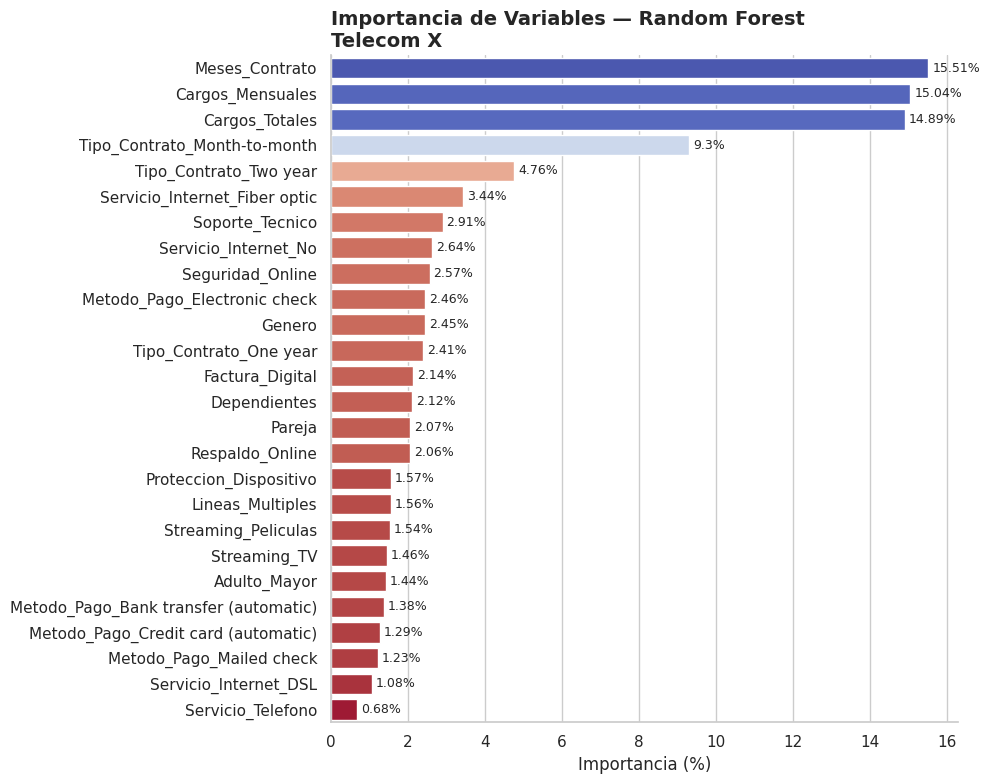

In [27]:
# Extraer el modelo del pipeline
modelo_rf = pipeline_rf.named_steps['modelo']

importancias = pd.DataFrame({
    'Variable'   : X.columns,
    'Importancia': (modelo_rf.feature_importances_ * 100).round(2)
}).sort_values('Importancia', ascending=False).reset_index(drop=True)

# Visualización
fig, ax = plt.subplots(figsize=(10, 8))

sns.barplot(data=importancias, x='Importancia', y='Variable',
            hue='Importancia', palette='coolwarm_r', legend=False, ax=ax)

ax.set_title('Importancia de Variables — Random Forest\nTelecom X',
             fontsize=14, fontweight='bold', loc='left')
ax.set_xlabel('Importancia (%)', fontsize=12)
ax.set_ylabel('')
sns.despine()

for i, val in enumerate(importancias['Importancia']):
    ax.text(val + 0.1, i, f'{val}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

### Importancia de Variables — Regresión Logística

En la Regresión Logística, los coeficientes de cada variable indican su contribución
a la predicción de cancelación. Valores positivos aumentan la probabilidad de abandono,
mientras que valores negativos la reducen.

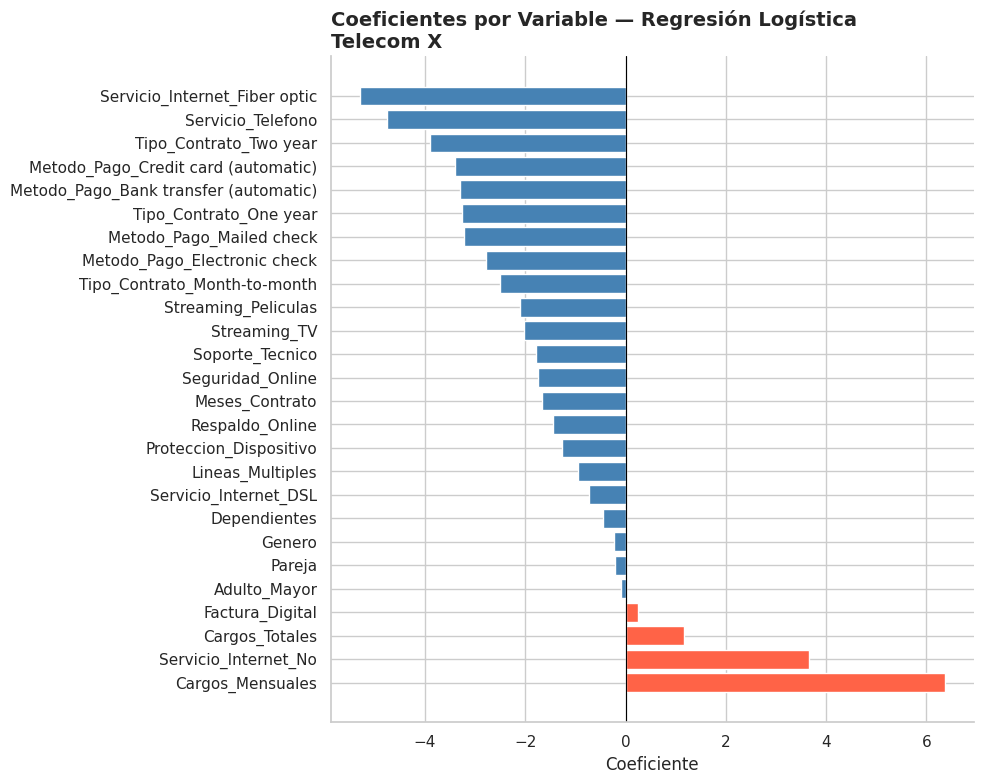

In [28]:
modelo_lr = pipeline_lr.named_steps['modelo']

coeficientes = pd.DataFrame({
    'Variable'   : X.columns,
    'Coeficiente': modelo_lr.coef_[0].round(3)
}).sort_values('Coeficiente', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 8))

colores = ['tomato' if c > 0 else 'steelblue' for c in coeficientes['Coeficiente']]

ax.barh(coeficientes['Variable'], coeficientes['Coeficiente'], color=colores)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title('Coeficientes por Variable — Regresión Logística\nTelecom X',
             fontsize=14, fontweight='bold', loc='left')
ax.set_xlabel('Coeficiente', fontsize=12)
ax.set_ylabel('')
sns.despine()

plt.tight_layout()
plt.show()

---

## 📄 Conclusiones e Insights

### Rendimiento de los Modelos

| Métrica | Reg. Logística | Random Forest |
|---|---|---|
| Accuracy | 77% | 77% |
| Precisión (Abandonó) | 55% | 56% |
| Recall (Abandonó) | **73%** | 63% |
| F1-Score (Abandonó) | **63%** | 59% |

La **Regresión Logística es el modelo recomendado** para este problema, ya que
obtiene un Recall de 73% en la clase de abandono — métrica prioritaria para Telecom X,
pues es más costoso no detectar a un cliente que se va que generar una alerta falsa.

---

### Variables más Influyentes

**Random Forest** identificó como variables más importantes:
- `Meses_Contrato` (15.51%), `Cargos_Mensuales` (15.04%) y `Cargos_Totales` (14.89%)
  dominan el modelo — los tres juntos explican casi el 45% de la predicción.
- `Tipo_Contrato_Month-to-month` (9.3%) es la variable categórica más relevante.

**Regresión Logística** refuerza estos hallazgos desde otra perspectiva:
- `Cargos_Mensuales` tiene el coeficiente positivo más alto (+6.2), indicando que
  a mayor cargo mensual, mayor probabilidad de abandono.
- `Servicio_Internet_Fiber optic` tiene el coeficiente negativo más fuerte (-4.8),
  lo que en conjunto con el análisis categórico sugiere que este servicio está
  asociado a perfiles de clientes con alta sensibilidad al precio.
- `Tipo_Contrato_Two year` y `Servicio_Telefono` reducen significativamente
  la probabilidad de abandono.

---

### Factores Principales de Cancelación

1. **Permanencia corta**: clientes con pocos meses de contrato tienen altísimo
   riesgo de cancelar — la primera barrera a superar es retenerlos en los primeros meses.
2. **Cargos elevados**: altos cargos mensuales sin percepción de valor generan abandono.
3. **Contrato mes a mes**: la flexibilidad del contrato facilita la cancelación impulsiva.
4. **Fibra óptica**: posible insatisfacción con la relación precio-calidad del servicio.
5. **Cheque electrónico**: método de pago asociado a menor compromiso con el servicio.

---

### Recomendaciones Estratégicas

| Área | Acción |
|---|---|
| **Retención temprana** | Programa de fidelización activo durante los primeros 3 meses |
| **Contratos** | Incentivos para migrar de mes a mes a contratos anuales o bianuales |
| **Fibra óptica** | Revisar satisfacción y percepción de valor del servicio |
| **Cargos** | Evaluar planes con precios escalonados para clientes con alto gasto mensual |
| **Modelo predictivo** | Desplegar la Regresión Logística para scoring mensual de riesgo de abandono |

---

Análisis desarrollado como parte del proyecto "Churn de Clientes" — Telecom X
Modelos: Regresión Logística y Random Forest | Herramientas: Python, Scikit-learn, Imbalanced-learn